# 09 · Feed-forward networks — `Sequential` and `MultiHead`

[`08_perceptron`](08_perceptron.ipynb) ended on the perceptron's one weakness: a
single linear unit can only cut the plane with a **straight** line, and some
problems have no straight cut. The fix is to stop using one unit — stack a
*layer* of them, feed that layer's outputs into another, and simple pieces
compose into an arbitrarily curved map.

`dolcestat` ships two containers for that, both in
[`networks.py`](../src/dolcestat/neural_networks/networks.py):

- **`Sequential(*layers)`** — a *chain*. Layer $i$'s output is layer $i+1$'s
  input, $f = f_k \circ \dots \circ f_1$: one array in, one array out.
- **`MultiHead(trunk, *heads)`** — a *branch*. One shared trunk feeds several
  independent heads, $\langle g_1, g_2\rangle \circ \text{trunk}$: one array in,
  a **tuple** out. Chaining can never produce that — the two heads are
  incomparable, neither precedes the other.

Nothing else here is new. The layers are the same `DenseLayer` the perceptron is
built from, the loop is the same `Trainer` you drove directly in
[`05_optimization`](05_optimization.ipynb), and the optimizers, samplers and
`History` are untouched. A network is a bigger *model* plugged into machinery
that already existed — which is why `fit`/`predict` read exactly like notebooks
02–03.

## The problem a single unit cannot solve

XOR, in continuous form: the label is `1` in the quadrants where $x_1$ and $x_2$
share a sign and `0` where they differ. We draw 100 points per quadrant, each at
least `0.4` away from both axes — so the classes are perfectly balanced and
cleanly separated *as regions*, just not by any one line.

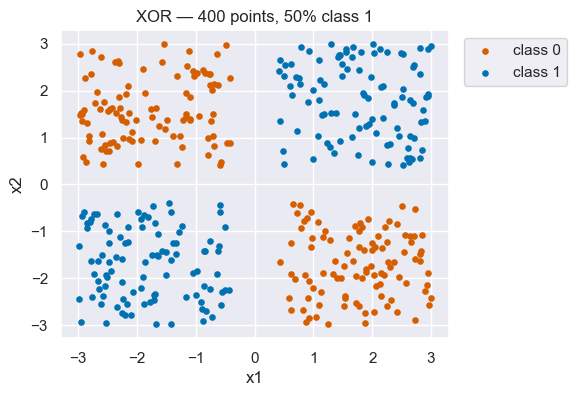

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

from dolcestat.core import (
    LU,
    BinaryCrossEntropy,
    GaussianNegativeLogLikelihood,
    MeanSquaredError,
    MiniBatchIteratingSampler,
    ReLU,
    Sigmoid,
    Softplus,
)
from dolcestat.metrics import ClassificationAnalyzer, RegressionAnalyzer
from dolcestat.neural_networks.layers import DenseLayer
from dolcestat.neural_networks.networks import MultiHead, Sequential
from dolcestat.optimization.analyzer import OptimizerAnalyzer
from dolcestat.optimization.gradient_descent import GradientDescent
from dolcestat.preprocessing import DolceSet

sns.set_theme()
BLUE, VERMILLION, GREEN, ORANGE = "#0072B2", "#D55E00", "#009E73", "#E69F00"

rng = np.random.default_rng(0)
X = np.vstack(
    [
        rng.uniform(0.4, 3.0, size=(100, 2)) * np.array([sx, sy])
        for sx, sy in [(1, 1), (-1, -1), (1, -1), (-1, 1)]
    ]
)
y = (X[:, 0] * X[:, 1] > 0).astype(int)          # 1 where the signs agree
shuffle = rng.permutation(len(y))
X, y = X[shuffle], y[shuffle]

xor = DolceSet()
xor.load_from_polars_dataframe(
    pl.DataFrame({"x1": X[:, 0], "x2": X[:, 1], "label": y}), target_col="label"
)

fig, ax = plt.subplots(figsize=(5, 4))
for cls, colour in [(0, VERMILLION), (1, BLUE)]:
    pts = X[y == cls]
    ax.scatter(pts[:, 0], pts[:, 1], s=14, c=colour, label=f"class {cls}")
ax.set(xlabel="x1", ylabel="x2", title=f"XOR — {len(y)} points, {y.mean():.0%} class 1")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.show()

## One unit versus two hidden layers

Two models, same data, same loss, same optimizer, same budget:

| | topology | what it is |
|---|---|---|
| **shallow** | `DenseLayer(Sigmoid(), 2, 1)` | one sigmoid unit — that *is* logistic regression ([`03`](03_logistic_regression.ipynb)) |
| **deep** | `2 → 8 → 8 → 1`, `ReLU` hidden, `Sigmoid` out | a feed-forward network |

Two rules govern how the layers are written:

- **Widths chain.** `DenseLayer(activation, input_size, output_size)`, and each
  layer's `input_size` must equal the previous layer's `output_size`. Only the
  first (the number of features) and the last (the number of outputs) are fixed
  by the problem; everything between is a modelling choice.
- **The output activation matches the loss.** `Sigmoid` + `BinaryCrossEntropy`
  for a probability — the pair whose gradients cancel exactly (see
  [`losses.py`](../src/dolcestat/core/losses.py)) — just as in notebook 03.
  Hidden layers are free to use whatever nonlinearity you like; `ReLU` is the
  default choice, and it must be a *non*-linearity: stacking linear layers only
  ever produces another linear map.

`fit` assembles a `Trainer` behind the scenes and stores the run in
`net.history`; `predict` runs the forward pass with `training=False`, leaving no
backward-pass cache behind. We pass `tol=None` so both runs spend the full
budget and their loss curves stay comparable.

One reproducibility note, since it bites: `HeInitializer` draws the starting
weights from NumPy's **global** RNG, and so does the mini-batch shuffle. The
seed therefore goes *before* the network is constructed, not merely before
`fit` — one seed then fixes the whole run.

In [2]:
def train(net, data, loss, n_epochs, alpha, momentum_type="nesterov", **kwargs):
    """Fits `net` and hands it back (`fit` returns self). Seed before calling."""
    return net.fit(
        data,
        loss=loss,
        n_epochs=n_epochs,
        optimizer=GradientDescent(
            alpha=alpha, momentum_type=momentum_type, momentum_rate=0.9
        ),
        tol=None,
        **kwargs,
    )


np.random.seed(0)          # before construction: the initializer draws from it too
shallow = train(
    Sequential(DenseLayer(Sigmoid(), 2, 1)),
    xor, BinaryCrossEntropy(), n_epochs=300, alpha=0.1,
)

np.random.seed(0)
deep = train(
    Sequential(
        DenseLayer(ReLU(), 2, 8),
        DenseLayer(ReLU(), 8, 8),
        DenseLayer(Sigmoid(), 8, 1),
    ),
    xor, BinaryCrossEntropy(), n_epochs=300, alpha=0.1,
)

accuracy = {}
for name, net in [("one sigmoid unit", shallow), ("two hidden layers", deep)]:
    report = ClassificationAnalyzer(xor.y, net.predict(xor.X).ravel())
    accuracy[name] = report.accuracy(threshold=0.5)
    print(
        f"{name:18s} | parameter arrays {len(net.get_parameters()):2d} | "
        f"accuracy {accuracy[name]:.3f} | final BCE {net.history.epoch_loss[-1]:.4f}"
    )

one sigmoid unit   | parameter arrays  2 | accuracy 0.500 | final BCE 0.7000
two hidden layers  | parameter arrays  6 | accuracy 1.000 | final BCE 0.0000


## What each of them learned

`predict` over a grid gives the class-1 probability everywhere, so the decision
regions can simply be shaded — the grey line is the `0.5` contour, the boundary
itself.

The single unit's boundary is a straight line, and no straight line beats chance
here: whichever way it is turned, it keeps half of each class on the wrong side.
Its loss curve flattens almost immediately because there is nothing left to
learn. The deep network's first `ReLU` layer contributes 8 hyperplanes, each
switched on or off per region; the second layer recombines those pieces, and the
output unit reads off a probability. The result is a piecewise-linear boundary
that closes around the quadrants.

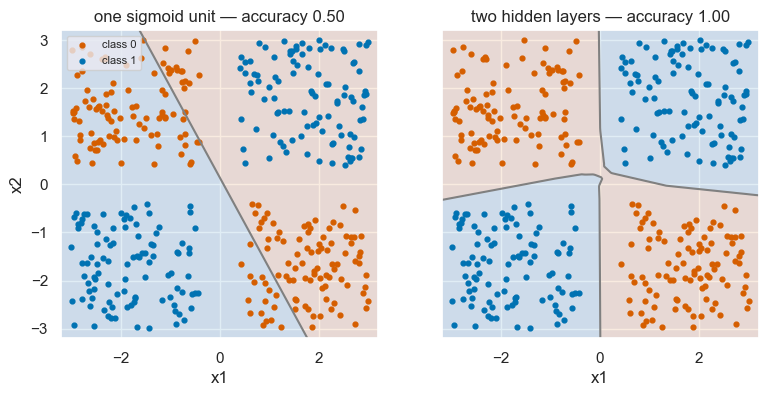

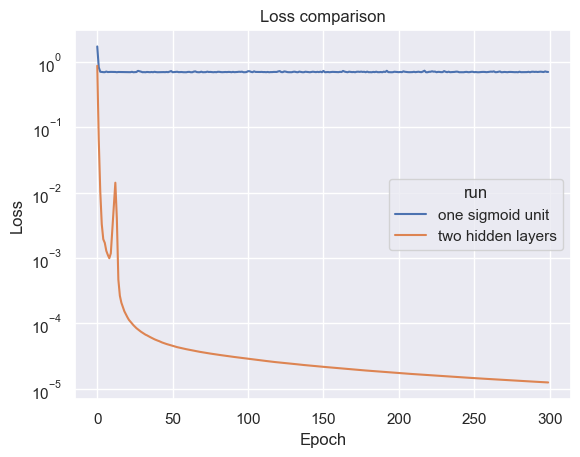

In [3]:
grid_x1, grid_x2 = np.meshgrid(np.linspace(-3.2, 3.2, 200), np.linspace(-3.2, 3.2, 200))
grid_points = np.column_stack([grid_x1.ravel(), grid_x2.ravel()])

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
for ax, (name, net) in zip(axes, [("one sigmoid unit", shallow), ("two hidden layers", deep)]):
    proba = net.predict(grid_points).reshape(grid_x1.shape)
    ax.contourf(grid_x1, grid_x2, proba, levels=[0.0, 0.5, 1.0],
                colors=[VERMILLION, BLUE], alpha=0.12)
    ax.contour(grid_x1, grid_x2, proba, levels=[0.5], colors="grey", linewidths=1.5)
    for cls, colour in [(0, VERMILLION), (1, BLUE)]:
        pts = X[y == cls]
        ax.scatter(pts[:, 0], pts[:, 1], s=12, c=colour, label=f"class {cls}")
    ax.set(xlabel="x1", title=f"{name} — accuracy {accuracy[name]:.2f}")
axes[0].set_ylabel("x2")
axes[0].legend(loc="upper left", fontsize=8)
plt.show()

OptimizerAnalyzer(
    [shallow.history, deep.history], labels=["one sigmoid unit", "two hidden layers"]
).plot_loss(log_scale=True)
plt.show()

## How much network do you actually need?

The **universal approximation theorem** says one hidden layer of sufficient
width can approximate any continuous function on a compact set to any accuracy.
That is a statement about *existence* — it promises nothing about how wide
"sufficient" is, nor that gradient descent will find those weights. So the
practical question is empirical: fit the same regression with growing capacity
and watch what happens.

The target is $y = \sin(1.5x) + 0.3x + \varepsilon$ with $\varepsilon \sim
N(0, 0.15^2)$. Because we know the truth, we can separate two very different
errors:

- **train RMSE** — distance to the *noisy observations*. It can never drop below
  the noise level 0.15; getting under it means memorising noise.
- **distance to $f$** — RMSE against the true curve on a dense grid. This is the
  quantity capacity is actually buying.

In [4]:
rng = np.random.default_rng(1)
n = 300
x = rng.uniform(-3, 3, n)
f = lambda t: np.sin(1.5 * t) + 0.3 * t
y_reg = f(x) + rng.normal(0, 0.15, n)

regression = DolceSet()
regression.load_from_polars_dataframe(pl.DataFrame({"x": x, "y": y_reg}), target_col="y")

grid = np.linspace(-3, 3, 200).reshape(-1, 1)
truth = f(grid.ravel())


def mlp(*widths):
    """ReLU stack of the given hidden widths, ending in one linear output unit."""
    sizes = (1,) + widths
    hidden = [DenseLayer(ReLU(), sizes[i], sizes[i + 1]) for i in range(len(widths))]
    return Sequential(*hidden, DenseLayer(LU(), sizes[-1], 1))


fits = {}
for label, widths in [("no hidden layer", ()), ("1 x 4", (4,)),
                      ("1 x 16", (16,)), ("2 x 16", (16, 16))]:
    np.random.seed(0)      # identical starting point for every topology
    fits[label] = train(mlp(*widths), regression, MeanSquaredError(),
                        n_epochs=400, alpha=0.005)

print(f"{'topology':16s} {'params':>7s} {'train RMSE':>11s} {'distance to f':>14s}")
for label, net in fits.items():
    n_params = sum(p.value.size for p in net.get_parameters())
    rmse = RegressionAnalyzer(regression.y, net.predict(regression.X).ravel()).rmse()
    to_truth = np.sqrt(np.mean((net.predict(grid).ravel() - truth) ** 2))
    print(f"{label:16s} {n_params:7d} {rmse:11.3f} {to_truth:14.3f}")
print(f"{'noise floor':16s} {'':7s} {0.15:11.3f} {0.0:14.3f}")

topology          params  train RMSE  distance to f
no hidden layer        2       0.710          0.693
1 x 4                 13       0.363          0.330
1 x 16                49       0.191          0.143
2 x 16               321       0.145          0.056
noise floor                    0.150          0.000


Reading the table: the linear model (no hidden layer) is off the true curve by
`0.69` and cannot improve — a straight line is all it has. One hidden layer of
width 4 halves that, width 16 gets within `0.14`, and two width-16 layers reach
`0.06`. Meanwhile the largest network's train RMSE (`0.145`) has slipped just
*under* the noise level: it is starting to fit $\varepsilon$ rather than $f$,
which is exactly what the "distance to $f$" column exists to catch.

The loss curves say the same thing from the optimizer's side. Every run starts
from the same seed and uses the identical learning rate and budget, so the gap
between the curves is capacity, not tuning: the linear model plateaus within a
few epochs, the width-4 net settles onto its own floor, and only the wider ones
reach the noise level. The fuzz along the bottom is real — `epoch_loss` is a
full-dataset evaluation, but the weights it evaluates are still being jostled by
mini-batch gradient noise.

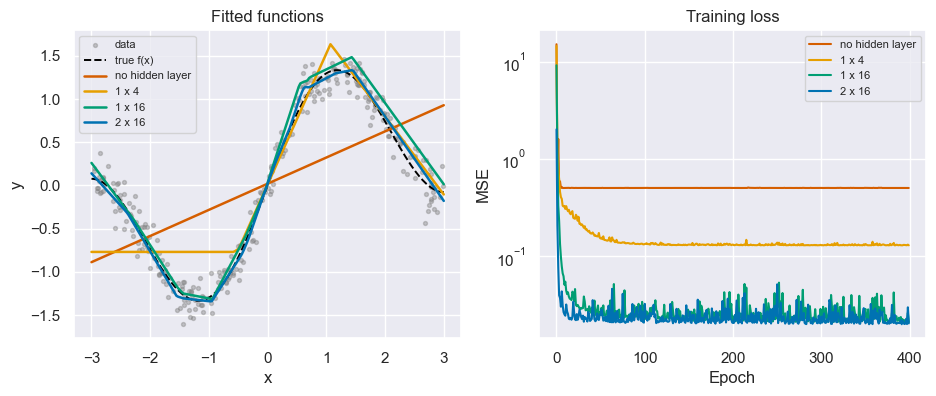

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(x, y_reg, s=8, c="grey", alpha=0.4, label="data")
axes[0].plot(grid, truth, ls="--", c="black", lw=1.4, label="true f(x)")
for (label, net), colour in zip(fits.items(), [VERMILLION, ORANGE, GREEN, BLUE]):
    axes[0].plot(grid, net.predict(grid).ravel(), c=colour, lw=1.8, label=label)
axes[0].set(xlabel="x", ylabel="y", title="Fitted functions")
axes[0].legend(fontsize=8)

for (label, net), colour in zip(fits.items(), [VERMILLION, ORANGE, GREEN, BLUE]):
    axes[1].plot(net.history.epoch_loss, c=colour, lw=1.5, label=label)
axes[1].set(xlabel="Epoch", ylabel="MSE", yscale="log", title="Training loss")
axes[1].legend(fontsize=8)
plt.show()

> The right-hand panel is what `OptimizerAnalyzer([...], labels=[...]).plot_loss(log_scale=True)`
> draws for you (notebooks [02](02_linear_regression.ipynb) and
> [05](05_optimization.ipynb)); we draw it by hand only so each network keeps the
> same colour it has in the left panel.

## Two answers from one input: `MultiHead`

Every model so far returns one number per row. Plenty of questions need more
than one: the mean *and* the spread of a prediction, the components of a
mixture, a policy *and* a value. Those cannot be a `Sequential` — a chain has
one output — so `MultiHead` runs a shared **trunk** once and feeds its output to
several independent **heads**.

Only one piece of new mathematics is involved, and it lives in `backward`. The
trunk's output $h$ now feeds several consumers, so by the multivariate chain
rule each trunk activation's total derivative is the **sum** over the paths that
use it:

$$\frac{\partial L}{\partial h} = \sum_{\text{heads}} \frac{\partial L}{\partial h}\Big|_{\text{that head}}$$

Each head backpropagates independently down to $h$, the contributions are added,
and the trunk sees a single gradient — after which everything downstream (the
optimizer, the `History`, the loop) is exactly as before.

### The example: heteroscedastic regression

The standard regression assumption is that the noise has the *same* scale
everywhere. Drop it, and the model must predict where the target sits **and**
how noisy it is there: $y \sim N(\mu(x), \sigma^2(x))$, whose negative
log-likelihood is

$$L_i = \tfrac{1}{2}\log\!\big(2\pi\sigma^2(x_i)\big) + \frac{(y_i - \mu(x_i))^2}{2\sigma^2(x_i)}$$

That is `GaussianNegativeLogLikelihood`, and two of its derivatives explain the
whole design:

- $\partial L_i/\partial \sigma^2 = 0$ exactly when $\sigma^2 = (y_i-\mu)^2$ —
  the maximum-likelihood variance. *That* is why a second head, given only this
  loss, learns the noise scale.
- $\partial L_i/\partial \mu = (\mu - y_i)/\sigma^2$ — each residual is weighted
  by the model's own confidence, so points it believes are noisy pull the mean
  less. Freeze $\sigma^2 = 1$ and this is squared error again (up to a factor of
  2): MSE *is* the homoscedastic special case.

Being a log-density rather than a distance, this loss is **not** bounded below
by zero — a training curve that dips negative is working, not broken.

Our data: $\mu(x) = \sin x$ with noise growing steadily from $\sigma = 0.10$ on
the left to $\sigma = 0.50$ on the right.

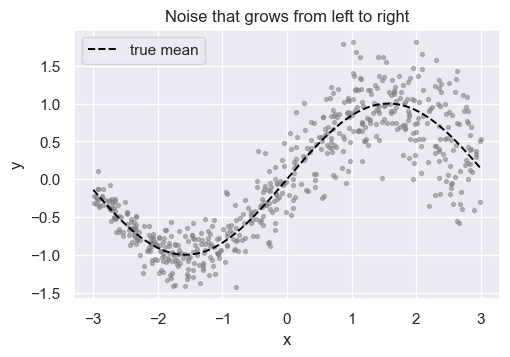

In [6]:
mean_fn = lambda t: np.sin(t)
sigma_fn = lambda t: 0.10 + 0.40 * (t + 3) / 6      # 0.10 on the left, 0.50 on the right

rng = np.random.default_rng(2)
x_h = rng.uniform(-3, 3, 600)
y_h = mean_fn(x_h) + rng.normal(0, 1, 600) * sigma_fn(x_h)

hetero = DolceSet()
hetero.load_from_polars_dataframe(pl.DataFrame({"x": x_h, "y": y_h}), target_col="y")

# A held-out sample, for an honest look at calibration later on.
x_test = rng.uniform(-3, 3, 400)
y_test = mean_fn(x_test) + rng.normal(0, 1, 400) * sigma_fn(x_test)
X_test = x_test.reshape(-1, 1)

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.scatter(x_h, y_h, s=8, c="grey", alpha=0.5)
ax.plot(grid, mean_fn(grid.ravel()), c="black", ls="--", lw=1.4, label="true mean")
ax.set(xlabel="x", ylabel="y", title="Noise that grows from left to right")
ax.legend()
plt.show()

### Building and fitting it

The trunk is an ordinary `Sequential`; the heads are one `DenseLayer` each,
sharing the trunk's output width of 32 but free to differ in everything else.
Their activations are again dictated by what they emit: `LU` for a mean that may
be any real number, `Softplus` for a variance that must stay strictly positive
(with `eps=1e-3`, which also bounds the $1/(2\sigma^4)$ gradient a collapsing
variance head would otherwise receive).

Two heads coupled through one likelihood optimize less kindly than a single
regression head, and they fail *quietly* — a variance head that gives up just
predicts a constant, and you get the homoscedastic answer back. The docstring on
`GaussianNegativeLogLikelihood` lists the countermeasures; we use all of them:
a target of order 1, a small learning rate with **no** momentum, batches large
enough to estimate a second moment, and a **warm-up** that fits the mean against
plain `MeanSquaredError` first, so the variance head starts from honest
residuals. The warm-up needs no new machinery — a `Sequential` holds its layers
by *reference*, so a throwaway chain of the trunk's and mean head's layers
trains the very same `Parameters` objects.

In [7]:
np.random.seed(0)
trunk = Sequential(DenseLayer(ReLU(), 1, 32), DenseLayer(ReLU(), 32, 32))
net = MultiHead(
    trunk,
    DenseLayer(LU(), 32, 1),                    # mu    -> the whole real line
    DenseLayer(Softplus(eps=1e-3), 32, 1),      # sigma^2 -> strictly positive
)
print("parameter arrays:", len(net.get_parameters()), "(trunk 4 + 2 per head)")

# 1. Warm up the trunk and the mean head on squared error. Same layer objects.
warm_up = Sequential(*net.trunk.layers, *net.heads[0].layers)
train(warm_up, hetero, MeanSquaredError(), n_epochs=200, alpha=0.01,
      sampler=MiniBatchIteratingSampler(batch_size=64))
print(f"after warm-up      : MSE {warm_up.history.epoch_loss[-1]:.4f}")

# 2. Now train both heads jointly under the likelihood. No momentum here.
train(net, hetero, GaussianNegativeLogLikelihood(), n_epochs=1000, alpha=0.01,
      momentum_type=None, sampler=MiniBatchIteratingSampler(batch_size=64))
print(f"after joint fit    : NLL {net.history.epoch_loss[-1]:.4f} "
      f"(started at {net.history.epoch_loss[0]:.4f})")

mu, var = net.predict(grid)          # a MultiHead returns one array per head
sigma = np.sqrt(var).ravel()
print(f"predicted sigma    : {sigma[0]:.2f} at x=-3, {sigma[-1]:.2f} at x=+3 "
      f"(true {sigma_fn(-3):.2f} and {sigma_fn(3):.2f})")

parameter arrays: 8 (trunk 4 + 2 per head)


after warm-up      : MSE 0.1063


after joint fit    : NLL 0.1993 (started at 0.9014)
predicted sigma    : 0.14 at x=-3, 0.50 at x=+3 (true 0.10 and 0.50)


The single-headed baseline for comparison is the network we already know how to
build: same trunk shape, one `LU` output, `MeanSquaredError`. It has no way to
express a varying spread, so the best it can offer is one constant $\sigma$ — the
standard deviation of its residuals.

homoscedastic sigma: 0.321 everywhere


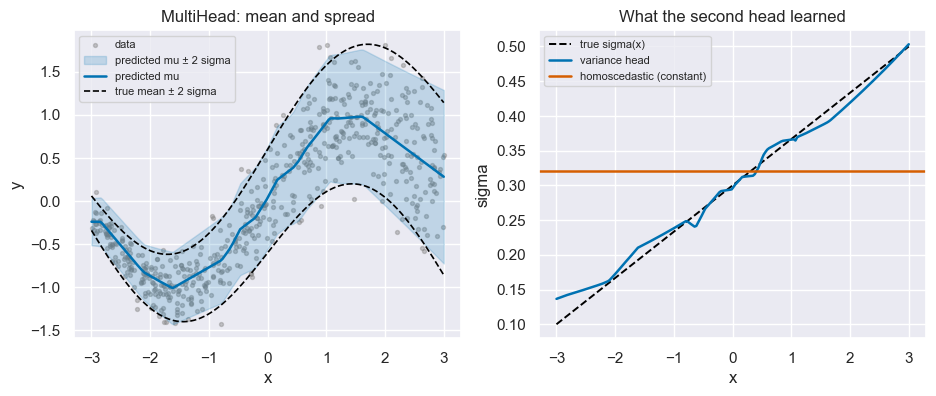

In [8]:
np.random.seed(0)
homoscedastic = train(
    mlp(32, 32), hetero, MeanSquaredError(), n_epochs=400, alpha=0.01,
    sampler=MiniBatchIteratingSampler(batch_size=64),
)
sigma_const = (hetero.y - homoscedastic.predict(hetero.X).ravel()).std()
print(f"homoscedastic sigma: {sigma_const:.3f} everywhere")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(x_h, y_h, s=8, c="grey", alpha=0.4, label="data")
axes[0].fill_between(grid.ravel(), (mu.ravel() - 2 * sigma), (mu.ravel() + 2 * sigma),
                     color=BLUE, alpha=0.18, label="predicted mu ± 2 sigma")
axes[0].plot(grid, mu.ravel(), c=BLUE, lw=1.8, label="predicted mu")
axes[0].plot(grid, mean_fn(grid.ravel()) + 2 * sigma_fn(grid.ravel()),
             c="black", ls="--", lw=1.2, label="true mean ± 2 sigma")
axes[0].plot(grid, mean_fn(grid.ravel()) - 2 * sigma_fn(grid.ravel()),
             c="black", ls="--", lw=1.2)
axes[0].set(xlabel="x", ylabel="y", title="MultiHead: mean and spread")
axes[0].legend(fontsize=8, loc="upper left")

axes[1].plot(grid, sigma_fn(grid.ravel()), c="black", ls="--", lw=1.4, label="true sigma(x)")
axes[1].plot(grid, sigma, c=BLUE, lw=1.8, label="variance head")
axes[1].axhline(sigma_const, c=VERMILLION, lw=1.8, label="homoscedastic (constant)")
axes[1].set(xlabel="x", ylabel="sigma", title="What the second head learned")
axes[1].legend(fontsize=8)
plt.show()

### Judge it by calibration, not by RMSE

Both models put their mean in almost the same place, so RMSE cannot tell them
apart — the difference is entirely in the *interval*. The test is **coverage**:
for a well-calibrated Gaussian model roughly **68%** of held-out targets fall
within one predicted $\sigma$ of $\mu$, and — this is the part a constant
$\sigma$ cannot fake — that should hold in *every* region of the input space,
not merely on average.

In [9]:
mu_test, var_test = net.predict(X_test)
region = np.digitize(x_test, [-1, 1])          # left / middle / right thirds
covered = {
    "MultiHead (sigma varies)": np.abs(y_test - mu_test.ravel()) < np.sqrt(var_test.ravel()),
    "Sequential (sigma fixed)": np.abs(y_test - homoscedastic.predict(X_test).ravel()) < sigma_const,
}

print(f"{'held-out coverage':26s} {'overall':>8s} {'x < -1':>8s} {'|x| < 1':>8s} {'x > 1':>8s}")
for label, inside in covered.items():
    by_region = [inside[region == k].mean() for k in range(3)]
    print(f"{label:26s} {inside.mean():8.2f}" + "".join(f"{c:8.2f}" for c in by_region))
print(f"{'target':26s} {0.68:8.2f}{0.68:8.2f}{0.68:8.2f}{0.68:8.2f}")

held-out coverage           overall   x < -1  |x| < 1    x > 1
MultiHead (sigma varies)       0.71    0.75    0.69    0.69
Sequential (sigma fixed)       0.74    0.95    0.71    0.56
target                         0.68    0.68    0.68    0.68


Overall, both land near 68% — averaged over the whole input space, a constant
$\sigma$ looks fine. Split by region and the fixed-$\sigma$ model falls apart: it
is far too cautious on the quiet left (covering ~95% of points, i.e. intervals
roughly twice as wide as they need to be) and far too confident on the noisy
right (~56%). The `MultiHead` stays close to 68% everywhere, because its second
head learned $\sigma(x)$ itself.

## Recap

- **`Sequential`** chains layers. Widths must agree, hidden activations must be
  non-linear, and the output activation is chosen to pair with the loss
  (`LU`+`MeanSquaredError`, `Sigmoid`+`BinaryCrossEntropy`).
- **Depth and width buy shape.** A network fits curves a line cannot, up to the
  noise floor — past which extra capacity fits noise.
- **`MultiHead`** branches: one trunk, several heads, one gradient per head, and
  their **sum** flowing back into the trunk. With
  `GaussianNegativeLogLikelihood` and an `LU`/`Softplus` pair of heads, that is
  heteroscedastic regression — a model that reports its own uncertainty.
- **Nothing about training changed.** The same `Trainer`, `GradientDescent`,
  samplers and `History` from [`05_optimization`](05_optimization.ipynb) run all
  of it; only the model object got bigger.

The two-head Gaussian is the smallest interesting case of a network that outputs
the parameters of a *distribution* rather than a point. Give it $k$ mean heads,
$k$ variance heads and a softmax gate and the same construction becomes a
mixture density network — the natural next step from here.